<h1 style="color:purple" align="left">Clustering vía Propagación de Afinidad</h1>

Las técnicas para detectar los patrones subyacentes en nuestros datos son ampliamente utilizadas en el análisis y la caracterización de la información. Exploraremos la técnica de **propagación de afinidades**, un método publicado hace aproximadamente 15 años en la prestigiosa revista *Science*. Esta técnica parte del supuesto de que cada punto del conjunto de datos puede comunicarse con los demás, buscando maximizar la afinidad entre ellos para formar clusters.

**Ventajas**

Una de las grandes ventajas de la propagación de afinidades es que **no requiere especificar de antemano el número de clusters**. El algoritmo recibe únicamente los datos de entrada y, a partir de ellos, es capaz de detectar los grupos existentes. Por ejemplo, en la gráfica que se muestra a la izquierda se observa cómo, utilizando solo seis puntos, el algoritmo identifica dos clusters —uno de color morado y otro de color verde— sin habérselos indicado previamente. Además, ciertos puntos se destacan con un contorno plateado; estos se conocen como **ejemplares** y representan los centros de cada cluster.

**Funcionamiento del algoritmo**

El funcionamiento del algoritmo se basa en el intercambio iterativo de dos tipos de mensajes entre los puntos:

**1. Comunicación entre puntos:**

Cada punto de los datos intercambia mensajes con los demás, buscando maximizar la afinidad entre ellos. Esto permite agrupar aquellos puntos que, en función de la similitud, se consideran coherentes para formar un cluster.

**2. Matriz de Similitud:**

- El algoritmo parte de la creación de una matriz de similitud, en la que se calcula, para cada par de puntos, la distancia euclidiana al cuadrado. Dado que el problema se formula como uno de maximización, estas similitudes se expresan en valores negativos (una mayor cercanía se traduce en un valor menos negativo). Además, se puede incorporar una “preferencia” para cada punto, lo que permite introducir conocimiento previo del dominio (por ejemplo, considerando ciertos datos como prototipos) y, en consecuencia, influir en la formación de los clusters.

**3. Mensajes de Responsabilidad y Disponibilidad:**

- **Responsabilidad:** Este mensaje expresa la confianza que un punto deposita en otro para que actúe como su representante (ejemplar). La responsabilidad se fundamenta en la similitud entre los puntos, usualmente medida mediante la **distancia euclidiana**. Por ejemplo, un punto puede “admirar” a otro si ambos son muy similares, mientras que la admiración se reduce cuando la distancia entre ellos es mayor.

- **Disponibilidad:** Indica cuánto "apoyo" recibe un punto para ser considerado como ejemplar desde la perspectiva de los demás. Es decir, resume la evidencia colectiva de que dicho punto es un buen representante del cluster. Sin embargo, esto es completamente **opcional**; podemos decidir que todos los nodos tengan la misma disponibilidad y, por lo tanto, la misma prioridad para convertirse en ejemplares.

  - Ejemplo: Podríamos contar con datos que representen un cliente prototipo para cierto tipo de productos y, simultáneamente, disponer de información que consideramos representativa de clientes prototipos para algún tipo de servicio. Al incorporar este conocimiento del negocio en el algoritmo de propagación de afinidades, es posible sesgar, hasta cierto punto, la selección y detección de puntos ejemplares.

Estos mensajes se intercambian de forma interactiva hasta que se alcanza la convergencia, es decir, hasta que los clusters dejan de cambiar. Un aspecto interesante de la propagación de afinidades es la posibilidad de incorporar **preferencias** para cada punto. Esto permite guiar la selección de los ejemplares cuando se cuenta con conocimientos previos o se dispone de datos representativos (por ejemplo, prototipos de clientes para ciertos productos o servicios). No obstante, esta opción es completamente opcional, ya que, en ausencia de preferencias, todos los puntos tienen la misma probabilidad de convertirse en ejemplares.

---

**Factor de amortiguación (dumping)**

En el algoritmo de Affinity Propagation, los valores de responsabilidad y disponibilidad se actualizan en cada iteración. Si esos valores cambian de forma brusca (es decir, aumentan o disminuyen mucho en cada paso), el algoritmo podría oscilar y no llegar a una solución estable (convergencia).

¿Qué es el factor de amortiguación o decaimiento?
- Es un valor (entre 0 y 1) que suaviza los cambios en cada actualización, combinando el valor nuevo con una parte del valor anterior. Esto ayuda a estabilizar el proceso y evitar esas oscilaciones bruscas.

Ventaja:
- Evita que el algoritmo entre en un ciclo infinito (oscilación).
- Facilita que el proceso de actualización sea más estable y llegue a una solución óptima.

**Condicion de terminación:**

En **Affinity Propagation**, la condición de terminación del algoritmo puede definirse de dos maneras principales:

### 1. **Número máximo de iteraciones** (condición por defecto)
   - El algoritmo finaliza después de un número fijo de iteraciones, incluso si aún no ha convergido.  
   - En `scikit-learn`, el parámetro `max_iter` define este límite (por defecto es `200`).
   
   ```python
   AffinityPropagation(max_iter=200)
   ```

### 2. **Convergencia basada en la estabilidad de las asignaciones** (condición preferida)
   - El algoritmo termina si las asignaciones de los clusters **no cambian** durante un número consecutivo de iteraciones.  
   - Esto garantiza que el algoritmo ha encontrado una solución estable (convergencia).  
   - En `scikit-learn`, esto se controla con el parámetro `convergence_iter` (por defecto es `15`).  
   - Esto significa que si las asignaciones no cambian en las últimas 15 iteraciones, el algoritmo se detiene.

   ```python
   AffinityPropagation(convergence_iter=15)
   ```

### ¿Cómo funciona la convergencia?
En cada iteración, el algoritmo actualiza las matrices de **responsabilidad** y **disponibilidad**, y luego revisa si las asignaciones de cluster han cambiado respecto a la iteración anterior.  
- Si las asignaciones permanecen iguales durante `convergence_iter` iteraciones, se asume que el algoritmo ha convergido y termina.  
- Si no lo hace antes del número máximo de iteraciones (`max_iter`), se detiene igualmente.

### Ejemplo de código para ajustar estas condiciones:
```python
from sklearn.cluster import AffinityPropagation

clustering = AffinityPropagation(max_iter=300, convergence_iter=20, random_state=0).fit(X)
```

- **max_iter=300:** Se permiten hasta 300 iteraciones.  
- **convergence_iter=20:** El algoritmo se detiene si las asignaciones no cambian durante 20 iteraciones consecutivas.

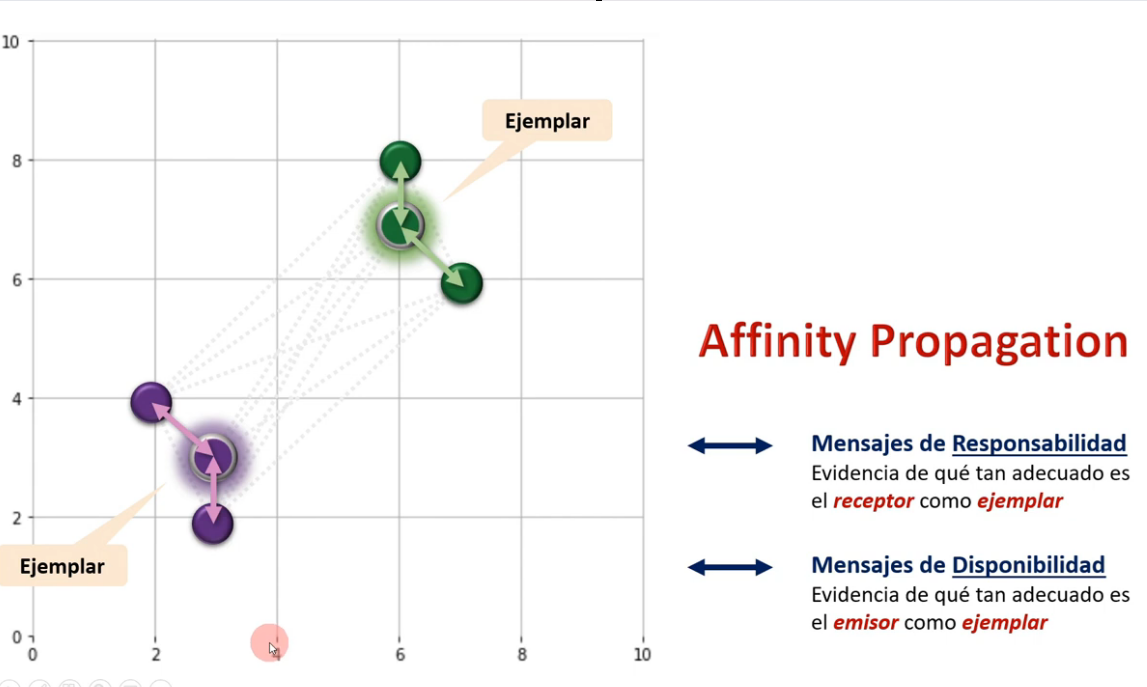

<h1 style="color:IndianRed">Affinity Propagation: Contexto y Datos</h1>

El dataset representa los mismos puntos que en la grafica anterior y represnta el ahorro de 6 personas y de cada una de estas personas estos datos corresponden al ahorro que tienen y una evaluacion crediticia correspondiente a esa persona.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation

datos = {"alan" : [2, 4],
         "alberto" : [3, 3],
         "alex" : [3, 2],
         "zelda" : [7, 6],
         "zoila" : [6, 7],
         "zulema" : [6, 8]}

personas = set(datos.keys())
datos = pd.DataFrame(datos, index=["ahorro", "evaluacion"])
datos

,alan,alberto,alex,zelda,zoila,zulema
ahorro,2,3,3,7,6,6
evaluacion,4,3,2,6,7,8


In [ ]:
datos.T

,ahorro,evaluacion
alan,2,4
alberto,3,3
alex,3,2
zelda,7,6
zoila,6,7
zulema,6,8


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Visualización de Datos</h1>

Vamos a imprimir por pantalla los valores de las variables ahorro y evaluación separando los primeros registros de los últimos.
El objetivo es comprobar cómo se distribuyen los datos antes de representarlos gráficamente y observar si existen grupos naturales.
Esto ayuda a anticipar visualmente la posible formación de clusters y facilita interpretar después el gráfico y el resultado del algoritmo.

In [ ]:
print(datos.T[0:3]["ahorro"]) # Valores de las 3 primeras observaciones (Grupo A) pasan los nombres a filas
print(datos.T[0:3]["evaluacion"])
print(datos.T[3:]["ahorro"])
print(datos.T[3:]["evaluacion"])

alan       2
alberto    3
alex       3
Name: ahorro, dtype: int64
alan       4
alberto    3
alex       2
Name: evaluacion, dtype: int64
zelda     7
zoila     6
zulema    6
Name: ahorro, dtype: int64
zelda     6
zoila     7
zulema    8
Name: evaluacion, dtype: int64


/tmp/ipython-input-3060659383.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(datos[datos.columns[i]][0]+0.3,
/tmp/ipython-input-3060659383.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  datos[datos.columns[i]][1]+0.3,


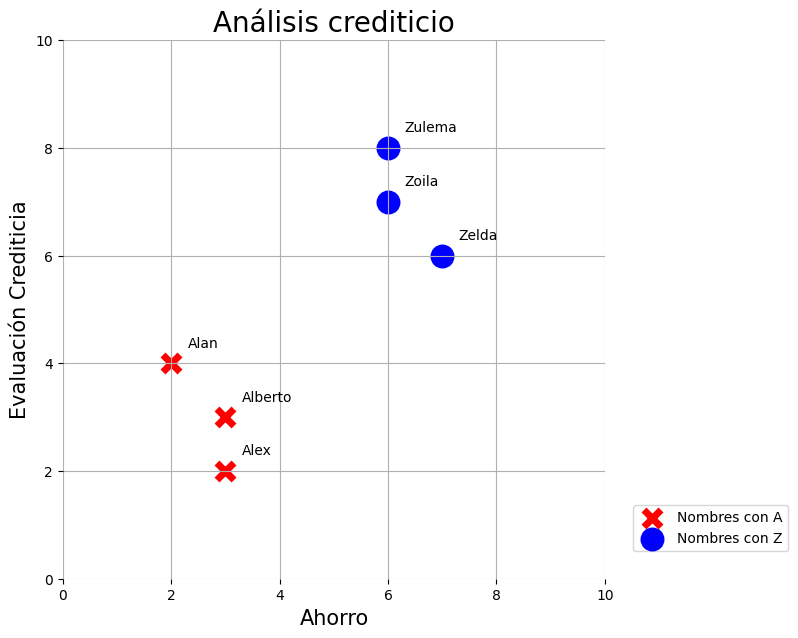

In [ ]:
plt.figure(figsize=(7, 7))
plt.title("Análisis crediticio", fontsize=20)

plt.scatter(datos.T[0:3]["ahorro"],
            datos.T[0:3]["evaluacion"],
            marker="x", s=150, color="red",
            linewidths=5, label="Nombres con A")

plt.scatter(datos.T[3:]["ahorro"],
            datos.T[3:]["evaluacion"],
            marker="o", s=150, color="blue",
            linewidths=5, label="Nombres con Z")

for i in range(len(datos.columns)):
    plt.text(datos[datos.columns[i]][0]+0.3,
             datos[datos.columns[i]][1]+0.3,
             datos.columns[i].capitalize())

plt.xlabel("Ahorro", fontsize=15)
plt.ylabel("Evaluación Crediticia", fontsize=15)
plt.legend(bbox_to_anchor=(1.35, 0.15))
plt.box(False)
plt.xlim((0, 10.01))
plt.ylim((0, 10.01))
plt.grid()
plt.show()

<h3><span style="color:purple" align="left">Affinity Propagation:</span> <span style="color:IndianRed" align="left"> Maximizar la similitud total entre los puntos y sus <span style="color:purple" align="left">Ejemplares</span></span></h3>

<br><br><br><br><br><br><br><br><br><br><br><br>
<h1 style="color:purple" align="left">Matrices para la Propagación de Afinidad</h1>
<ul>
  <li><h2 style="color:IndianRed">s : Similitud <span style="color:black">(Entrada)</span></h2></li>
  <li><h2 style="color:IndianRed">r : Responsabilidad</h2></li>
  <li><h2 style="color:IndianRed">d : Disponibilidad</h2></li>
  <li><h2 style="color:IndianRed">a : Asignaciones <span style="color:black">(Salida)</span></h2></li>
</ul>
<br><br><br><br><br><br><br><br><br><br><br><br>

<h1 style="color:purple" align="left">Similitud entre dos puntos i, k</h1>
<h2 style="color:purple" align="left">Métrica: <span style="color:IndianRed">Distancia euclidiana al cuadrado</span></h2>

Lo primero que tenemos que hacer es calcular una matriz de similitud, es decir, cuanto se parecen cada uno de los puntos al resto de puntos.

La similitud es la distancia de un punto a otro. Puntos cercanos tienen mas similitud, mientras que los lejanos tienen menos similitud.

Una de las medidas de distancia más comúnmente utilizadas es la **distancia euclidiana**. En este caso, por defecto se emplea la versión al cuadrado de la distancia euclidiana, ya que elevarla al cuadrado penaliza las distancias muy grandes y favorece las distancias muy pequeñas.

In [ ]:
datos

,alan,alberto,alex,zelda,zoila,zulema
ahorro,2,3,3,7,6,6
evaluacion,4,3,2,6,7,8


In [ ]:
datos["alan"]

,alan
ahorro,2
evaluacion,4


In [ ]:
#1. Elevamos al cuadrado para castigar las distancias que son muy grandes, y favorecer a las distancias pequeñas
#2. La razón por la que manejamos similitudes negativas es debido a la forma en que está planteado el algoritmo.
#   El objetivo del algoritmo es maximizar la similitud entre los puntos, y para lograr esto, se utiliza una formulación negativa de la similitud.
#   Este enfoque busca que la similitud aumente hasta llegar a cero, lo cual es el punto de convergencia en el proceso de maximización
print("Similitud entre Alan y Alberto", -((datos["alan"] - datos["alberto"])**2).sum())
print("Similitud entre Alan y Zulema", -((datos["alan"] - datos["zulema"])**2).sum()) #

Similitud entre Alan y Alberto -2
Similitud entre Alan y Zulema -32


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Creación de <span style="color:IndianRed">Matriz de Similitud</span> para i != k </h1>

In [ ]:
# Se crea una matriz vacía de similitudes con ceros.
# Las filas y columnas son las personas del dataset.
# Esta matriz guardará cuánto se parece cada persona a cada otra.
s = pd.DataFrame(0, columns=datos.columns, index=datos.columns)

for i in personas: # Recorremos cada persona i (la que queremos asignar a un posible ejemplar)
    for k in personas:  # Para cada persona i, comparamos su similitud con cada posible ejemplar k

        # Calculamos la similitud como el negativo de la distancia euclídea al cuadrado
        # (restamos los vectores de características, elevamos al cuadrado y sumamos)
        # El signo negativo se usa porque el algoritmo maximiza similitud,
        # así que puntos cercanos tendrán valores menos negativos (mayores).
        s.loc[i, k] = -((datos[i] - datos[k])**2).sum()

s

,alan,alberto,alex,zelda,zoila,zulema
alan,0,-2,-5,-29,-25,-32
alberto,-2,0,-1,-25,-25,-34
alex,-5,-1,0,-32,-34,-45
zelda,-29,-25,-32,0,-2,-5
zoila,-25,-25,-34,-2,0,-1
zulema,-32,-34,-45,-5,-1,0


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h2 style="color:purple" align="left">Preferencia a priori de cada punto como <span style="color:IndianRed">Ejemplar</span></h2> (Introduciendo información del negocio)


 Una característica muy importante de este algoritmo es la posibilidad de **incorporar preferencias basadas en el conocimiento del negocio**. Esto significa que, por ejemplo, puedo asignar distintos niveles de importancia a cada nodo: podría indicar qué tan relevante es Alan, o Alberto, o Álex para mí, considerando que alguno de ellos podría representar el cliente prototipo que estoy buscando, o incluso que ya conozca de antemano dos clases potenciales basadas en mi conocimiento del negocio.

Sin embargo, en este caso no vamos a aplicar preferencias arbitrarias o basadas en el negocio. En su lugar, asumiremos que todos los nodos son igual de importantes. Para lograrlo, **asignamos el valor mínimo en la diagonal de la matriz de similitud** (el articulo cientifico tambien dice que se puede usar la mediana), lo que equivale a decir que ningún nodo tendrá una preferencia inicial superior a otro. De esta manera, todos deberán ganarse su lugar como ejemplares en el proceso de clustering.

 la diagonal de la matriz de similitud representa la preferencia de cada nodo para ser un ejemplar (centro del cluster). Al asignar el valor más bajo de toda la matriz a la diagonal:

Se reduce la preferencia inicial para todos los nodos por igual.
Esto evita que el algoritmo tenga un sesgo inicial hacia cualquier nodo en particular.
Ejemplo:
Si el valor de la diagonal fuera más alto que el resto de la matriz, esos nodos tendrían una probabilidad mayor de ser seleccionados como ejemplares desde el inicio.

In [ ]:
np.fill_diagonal(s.values, np.min(s.values)) #calcula el valor mínimo y sustituye la diagonal de la matriz por ese valor

s

,alan,alberto,alex,zelda,zoila,zulema
alan,-45,-2,-5,-29,-25,-32
alberto,-2,-45,-1,-25,-25,-34
alex,-5,-1,-45,-32,-34,-45
zelda,-29,-25,-32,-45,-2,-5
zoila,-25,-25,-34,-2,-45,-1
zulema,-32,-34,-45,-5,-1,-45


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Mensajes de Disponibilidad</h1>
<h2 style="color:IndianRed" align="left">Evidencia de qué tan adecuado es
el emisor como <span style="color:purple">Ejemplar</span></h2>

Inicialmente el algoritmo parte de que no hay un nodo que se presuma mas que otro de ser centroide, es decir, todos parten de la misma disponibilidad.

En la matriz de disponibilidad podrías introducir **información del negocio** para dar preferencia a ciertos nodos como ejemplares iniciales. Esto sesgaría el algoritmo para que favorezca esos nodos como posibles centros del cluster.

### Ejemplo práctico:
Supongamos que tienes información previa del negocio que indica lo siguiente:
- **Alan** y **Zoila** son clientes **prototipo** de dos tipos diferentes de servicios.  
- Quieres que el algoritmo dé mayor preferencia a ellos como ejemplares.

Podrías modificar la diagonal de la matriz de disponibilidad para reflejar esta preferencia:

```python
# Asignamos una mayor preferencia a Alan y Zoila
d.loc['alan', 'alan'] = 10  # Preferencia alta para Alan
d.loc['zoila', 'zoila'] = 10  # Preferencia alta para Zoila
```

Esto significa que Alan y Zoila parten con mayor disponibilidad para ser considerados ejemplares desde el inicio.

### Cómo afecta esto:
- El algoritmo favorecerá a Alan y Zoila como **ejemplares** si no hay otra información más fuerte que sugiera otros nodos.  
- Esta técnica es útil cuando tienes datos o reglas del negocio que te permiten saber de antemano que ciertos puntos son mejores representantes para ciertos grupos.

In [ ]:
# Matriz de Disponibilidad
d = pd.DataFrame(0, columns=datos.columns, index=datos.columns)

d

,alan,alberto,alex,zelda,zoila,zulema
alan,0,0,0,0,0,0
alberto,0,0,0,0,0,0
alex,0,0,0,0,0,0
zelda,0,0,0,0,0,0
zoila,0,0,0,0,0,0
zulema,0,0,0,0,0,0


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>    
<h1 style="color:purple" align="left">Mensajes de Responsabilidad</h1>
<h2 style="color:IndianRed" align="left">Evidencia de qué tan adecuado es
el receptor como <span style="color:purple">Ejemplar</span></h2>

In [ ]:
# La responsabilidad se actualiza a partir de la similitud y la disponibilidad
s

,alan,alberto,alex,zelda,zoila,zulema
alan,-45,-2,-5,-29,-25,-32
alberto,-2,-45,-1,-25,-25,-34
alex,-5,-1,-45,-32,-34,-45
zelda,-29,-25,-32,-45,-2,-5
zoila,-25,-25,-34,-2,-45,-1
zulema,-32,-34,-45,-5,-1,-45


In [ ]:
# Responsabilidad ["alan", "alberto"]

sim = s.loc["alan", "alberto"]
# esta similitud es relativa a los otros nodos, por eso tenemos que calcular la similutud con los otros nodos
sim_otros = s.loc["alan", ["alan", "alex", "zelda", "zoila", "zulema"]]
# calculamos tambien la disponibilidad. Para calcular la responsabilidad que podemos tener sobre un nodo, lo hacemos en funcion de la disponibilidad
dis_otros = d.loc["alan", ["alan", "alex", "zelda", "zoila", "zulema"]]

#La similutud esta castigada por que tanto ven los otros nodos a otros potenciales ejemplares y que tanto es similar Alan a otros nodos
print("Qué tan adecuado es Alberto como EJEMPLAR para Alan:", sim - max(sim_otros + dis_otros))


sim = s.loc["alan", "zulema"]

sim_otros = s.loc["alan", ["alan", "alberto", "alex", "zelda", "zoila"]]

dis_otros = d.loc["alan", ["alan", "alberto", "alex", "zelda", "zoila"]]

# Responsabilidad ["alan", "zulema"]

print("Qué tan adecuada es Zulema como EJEMPLAR para Alan:", sim - max(sim_otros + dis_otros))


Qué tan adecuado es Alberto como EJEMPLAR para Alan: 3
Qué tan adecuada es Zulema como EJEMPLAR para Alan: -30


<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Algoritmo Principal - Actualización de Matrices:</h1>
<ul>
  <li><h2 style="color:IndianRed">r : Responsabilidad</h2></li>
  <li><h2 style="color:IndianRed">d : Disponibilidad</h2></li>
  <li><h2 style="color:IndianRed">a : Asignaciones</h2></li>
</ul>  

La matriz de similitud se calcula inicialmente a partir de los datos y, una vez definida, **no se actualiza**, ya que la relación entre los datos permanece constante. Sin embargo, esta matriz se emplea para actualizar las matrices de responsabilidades y de disponibilidad, las cuales, en conjunto, determinan la matriz de asignaciones que define a qué cluster pertenece cada nodo.

In [ ]:
# Matriz de Responsabilidad
r = pd.DataFrame(0, columns=datos.columns, index=datos.columns) #Matriz cuadrada con 0


for i in range(10): # 10 iteraciones

    factor = 0.5 # Suele ponerse 0,5, entre 0,6 y 0,8 es mejor y más estable. 0,9 es mucho mejor pero más lento.

    # Actualización de Responsabilidades

    r_anterior = r.copy() # Hacemos una copia

    #Actualizacion de las responsabilidades de un punto para todos los demas, iterativamente. A partir de la similitud y la disponibilidad (que en este punto todavia sigue siendo 0)
    for i in personas: # i es el punto que elige
        for k in personas: # k es el candidato a ejemplar
            elegibles = list(personas.difference({k})) # Se crea una lista de candidatos alternativos menos k
            r.loc[i, k] = s.loc[i, k] - max(s.loc[i, elegibles] + d.loc[i, elegibles])
    # Se utiliza un factor de amortiguación (o decaimiento) para suavizar la actualización y evitar oscilaciones. Esto se realiza combinando el valor recién calculado con el valor de la iteración anterior:
    #En el algoritmo de Affinity Propagation, los valores de responsabilidad y disponibilidad se actualizan en cada iteración.
    #Si esos valores cambian de forma brusca (es decir, aumentan o disminuyen mucho en cada paso), el algoritmo podría oscilar
    #y no llegar a una solución estable (convergencia).

    r = (1 - factor)*r + factor*r_anterior #Aplicamos damping en toda la matriz


    # Actualización de Disponibilidades

    d_anterior = d.copy()

    # Actualiza la disponibilidad de un nodo, para todos los demas nodos
    for i in personas:
        for k in personas:
            # Actualiza la disponibilidad para los datos que estan DENTRO de la diagonal
            # La disponibilidad de un nodo con respecto a sigo mismo, se calcula usando las responsabilidades que han sido depositadas en ellos, en concreto las solo responsabilidades positivas
            if i == k:
                elegibles = list(personas.difference({i}))
                d.loc[k, k] = r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum() # Se suman solo las responsabilidades positivas que otros envían a k
            # Actualiza la disponibilidad para los datos que estan FUERA de la diagonal
            # Se calcula de forma similar como teniamos en la diagonal, pero ademas le sumamos la responsabilidad que tiene el nodo consigo mismo. r.loc[k, k]
            else:
                elegibles = list(personas.difference({i, k}))
                d.loc[i, k] = min(0, r.loc[k, k] + r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum())

    d = (1 - factor)*d + factor*d_anterior

    # Actualización de Asignaciones

    a = r + d

/tmp/ipython-input-1155166430.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[k, k] = r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum() # Se suman solo las responsabilidades positivas que otros envían a k
/tmp/ipython-input-1155166430.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-21.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d.loc[i, k] = min(0, r.loc[k, k] + r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum())
/tmp/ipython-input-1155166430.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-21.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype firs

### Explicación Detallada del Proceso

1. **Actualización de la Matriz de Responsabilidades:**  
   - **Propósito:**  
     La responsabilidad representa la "admiración" que un nodo (por ejemplo, una persona) deposita en otro para que actúe como ejemplar del cluster.
   - **Proceso:**  
     - Se recorre cada par de nodos (i, k) utilizando dos bucles anidados.
     - Para cada par, se calcula la responsabilidad `r(i, k)` como:
       - La diferencia entre la similitud `s(i, k)` y el valor máximo de la suma `s(i, j) + d(i, j)` para todos los nodos *elegibles* (todos los nodos excepto k).
     - Se utiliza un factor de amortiguación (o decaimiento) para suavizar la actualización y evitar oscilaciones. Esto se realiza combinando el valor recién calculado con el valor de la iteración anterior:
       ```python
       r = (1 - factor) * r + factor * r_anterior
       ```

2. **Actualización de la Matriz de Disponibilidades:**  
   - **Propósito:**  
     La disponibilidad mide el "apoyo" o la evidencia colectiva de que un nodo debe ser considerado como ejemplar.
   - **Proceso:**  
     - También se recorre cada par de nodos (i, k) mediante dos bucles anidados.
     - **Para los elementos de la diagonal** (cuando i == k):
       - Se calcula la disponibilidad sumando las responsabilidades positivas de todos los nodos distintos de i. Esto refleja cuánto apoyo recibe el nodo para ser ejemplar:
         ```python
         d.loc[k, k] = r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum()
         ```
     - **Para los elementos fuera de la diagonal** (cuando i ≠ k):
       - Se toma el mínimo entre 0 y la suma de la responsabilidad `r(k, k)` más las responsabilidades positivas de los demás nodos con respecto a k:
         ```python
         d.loc[i, k] = min(0, r.loc[k, k] + r.loc[elegibles, k][r.loc[elegibles, k] > 0].sum())
         ```
     - Al igual que con las responsabilidades, se aplica un factor de amortiguación:
       ```python
       d = (1 - factor) * d + factor * d_anterior
       ```

3. **Actualización de la Matriz de Asignaciones:**  
   - Una vez actualizadas las matrices de responsabilidades (r) y disponibilidades (d), se calcula la matriz de asignaciones (a) sumando ambas:
     ```python
     a = r + d
     ```
   - Esta matriz final indica, para cada nodo, el valor total que determina su idoneidad para actuar como ejemplar y, en consecuencia, la asignación a un cluster.

4. **Iteraciones y Convergencia:**  
   - Todo el proceso descrito se repite durante un número determinado de iteraciones (en este ejemplo, 10).  
   - En cada iteración se actualizan primero las responsabilidades y luego las disponibilidades, de modo que ambos conjuntos de valores evolucionan de forma interdependiente.
   - Aunque en otros casos se podría definir un mayor número de iteraciones (por ejemplo, 15 o más) o utilizar criterios de convergencia (como la ausencia de cambios en las asignaciones), en este caso la constante de 10 iteraciones ha sido suficiente para obtener los clusters deseados.

### Resumen

- **Responsabilidades:** Se calculan para cada par de nodos y reflejan la "admiración" basada en la similitud, ajustada mediante un factor de amortiguación.
- **Disponibilidades:** Se actualizan tomando en cuenta las responsabilidades positivas, diferenciando entre los casos de la diagonal y los fuera de ella.
- **Asignaciones:** La suma de responsabilidades y disponibilidades determina a qué cluster se asigna cada nodo.

<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Matriz de Asignaciones</h1>

Tras iterar las matrices de responsabilidad y disponibilidad, se calcula la matriz de asignación como la suma de ambas.

Esta matriz refleja la evidencia total de que un punto pertenezca a cada posible ejemplar.

El ejemplar final de cada observación se determina seleccionando el valor máximo de su fila.

In [ ]:
# Se define el número de decimales que se mostrarán en pantalla
# Solo afecta a la visualización, no a los cálculos

np.set_printoptions(precision=2)

# Calcula el valor máximo de cada fila de la matriz de asignación
# Esto indica la evidencia máxima de pertenencia de cada punto a su ejemplar

print("Máximos", a.max(1).values)

# Obtiene la posición (columna) donde está ese máximo en cada fila
# Esa posición corresponde al ejemplar elegido para cada punto

print("Posición de los máximos", np.argmax(a.values, axis=1)) # “argument of the maximum” → la posición donde está el valor máximo

a.round(decimals=2)

Máximos [21.63 25.59 26.4  21.63 25.59 26.4 ]
Posición de los máximos [1 1 1 4 4 4]


,alan,alberto,alex,zelda,zoila,zulema
alan,-31.67,21.63,-30.44,-54.04,-20.28,-55.87
alberto,-32.36,25.59,-31.23,-48.59,-18.82,-56.41
alex,-31.62,26.40,-30.64,-56.80,-29.03,-68.62
zelda,-54.04,-20.28,-55.87,-31.67,21.63,-30.44
zoila,-48.59,-18.82,-56.41,-32.36,25.59,-31.23
zulema,-56.80,-29.03,-68.62,-31.62,26.40,-30.64


Del resultado se observa que:

- Para los primeros tres nodos (alan, alberto y alex):
El valor máximo en cada una de sus filas se encuentra en la columna de índice 1, correspondiente a alberto. Esto significa que estos nodos consideran a alberto como su ejemplar, ya que es el que obtiene el mayor "voto" o peso en la evaluación.

- Para los siguientes tres nodos (zelda, zoila y zulema):
El valor máximo en cada fila se encuentra en la columna de índice 4, correspondiente a zoila. Por lo tanto, estos nodos asignan a zoila como su ejemplar.

En resumen, la matriz nos indica que existen dos clusters:

- Un cluster conformado por los nodos que tienen a alberto como ejemplar (índice 1).
- Otro cluster formado por los nodos que asignan a zoila como ejemplar (índice 4).

Así, mediante la identificación de los valores máximos y sus posiciones en la matriz, determinamos cómo se agrupan los nodos y quién actúa como representante en cada cluster.

# ASIGNACION DE LOS PUNTOS A CADA CLUSTER

- Calcula la similitud de cada punto con todos los ejemplares (normalmente usando la métrica de similitud utilizada en el algoritmo, como la distancia euclidiana negativa).

- Asigna cada punto al cluster del ejemplar más cercano (el que tenga la mayor similitud o menor distancia).

<BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR><BR>
<h1 style="color:purple" align="left">Propagación de afinidad con <span style="color:IndianRed">Scikit-Learn</span></h1>

Una vez implementado el algoritmo de Propagación de Afinidad de forma manual, se utiliza la librería scikit-learn para validar los resultados obtenidos.

Esta implementación optimizada permite aplicar el algoritmo directamente sobre los datos, identificando automáticamente los ejemplares y las asignaciones de cluster.

El objetivo es comprobar que los centroides y agrupaciones obtenidos coinciden con los calculados manualmente, confirmando así la correcta aplicación del método.

In [ ]:
X = datos.T.values
clustering = AffinityPropagation(random_state=None).fit(X)
print("Etiquetas de Clusters:", clustering.labels_)
print("Índices de Centroides:", clustering.cluster_centers_indices_)

Etiquetas de Clusters: [0 0 0 1 1 1]
Índices de Centroides: [1 4]


- Obtenemos el punto 1 y el punto 4 como centroides
- La diferencia es que aqui reinicia el conteo de los clusters, pero el resultado es equivalente.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation

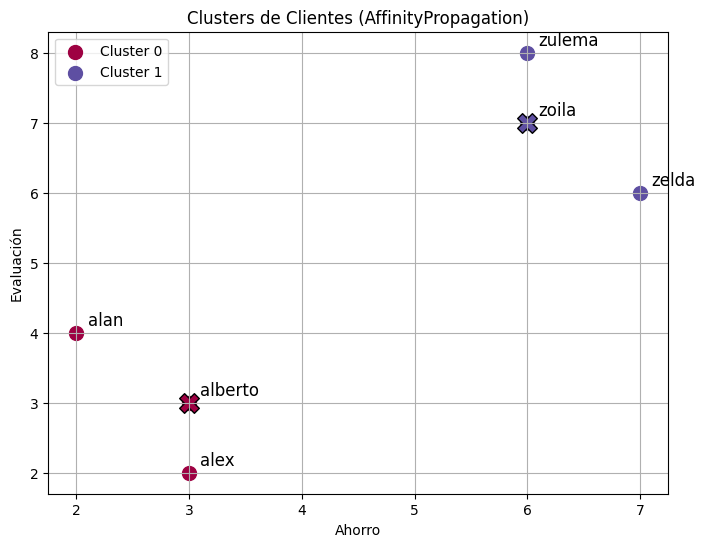

In [ ]:
X = datos.T.values
clustering = AffinityPropagation(random_state=None).fit(X)

labels = clustering.labels_
cluster_centers = clustering.cluster_centers_

# Configuramos la visualización de los clusters
plt.figure(figsize=(8, 6))

# Generamos una paleta de colores, uno para cada cluster
colors = plt.cm.Spectral(np.linspace(0, 1, len(np.unique(labels))))

# Recorremos cada cluster y graficamos sus puntos
for k, col in zip(np.unique(labels), colors):
    # Seleccionamos los puntos que pertenecen al cluster 'k'
    class_members = (labels == k)
    plt.scatter(X[class_members, 0], X[class_members, 1],
                c=[col], s=100, label=f'Cluster {k}')
    # Marcamos el centro del cluster con un marcador especial ('X')
    plt.scatter(cluster_centers[k, 0], cluster_centers[k, 1],
                marker='X', c=[col], s=200, edgecolor='k')

# Añadimos etiquetas a cada punto (nombre del cliente)
for i, nombre in enumerate(datos.columns):
    plt.text(X[i, 0] + 0.1,
             X[i, 1] + 0.1,
             nombre,
             fontsize=12)

# Configuramos los ejes y el título de la gráfica
plt.xlabel("Ahorro")
plt.ylabel("Evaluación")
plt.title("Clusters de Clientes (AffinityPropagation)")
plt.legend()
plt.grid(True)
plt.show()

## Resumen

En este trabajo hemos seguido el procedimiento habitual para aplicar el algoritmo de Propagación de Afinidad:

1. **Preparación de los datos**
Se definió el conjunto de puntos y sus variables, verificando visualmente su distribución para anticipar posibles agrupaciones.

2. **Construcción de la matriz de similitud**
Se calculó la similitud entre todos los pares de puntos mediante la distancia euclídea negativa al cuadrado, obteniendo la matriz que describe la relación entre observaciones.

3. **Definición de preferencias**
Se fijaron los valores de la diagonal de la matriz de similitud para controlar el número potencial de ejemplares (centros de cluster).

4. **Inicialización de los mensajes del algoritmo**
Se crearon las matrices de responsabilidades y disponibilidades, inicialmente sin información previa.

5. **Iteración del algoritmo de mensajes**
Se actualizaron iterativamente responsabilidades y disponibilidades, aplicando amortiguación para asegurar estabilidad y convergencia.

6. **Obtención de asignaciones finales**
Se sumaron ambas matrices para calcular la evidencia total de asignación, determinando automáticamente los ejemplares y los clusters resultantes.